# Open data

In [5]:
# Set up for saving and opening
import os
import numpy as np
import matplotlib.image as mpimg
from mike_utils import show_image, read_boxes

configs = {}
configs['lim_x'] = [0,53]
configs['lim_y'] = [-20,20]
configs['lim_z'] = [-3.1, 2]
configs['lim_r'] = [0, 1.0]
configs['bev_height'] = 640
configs['bev_width'] = 480
configs['yolo_width'] = 480
configs['yolo_height']= 480

context = '11718898130355901268_2300_000_2320_000:1558017561572660'
dataset_dir_yolo = '/home/mike_yolo/src/data/perception_2.0.0_yolov8'
path_img = os.path.join(dataset_dir_yolo, 'images', 'training', f'{context}cam.png')
path_lidar = os.path.join(dataset_dir_yolo, 'images', 'training', f'{context}lidar.png')
path_lbs = os.path.join(dataset_dir_yolo, 'labels', 'training', f'{context}.txt')

The shape of the data is (5, 10) an an example line is [4.00000000e+00 2.03362340e+02 2.23710692e+02 4.76146320e+01
 4.29762584e+01 7.91606899e-01 4.96985574e-01 6.65669234e-02
 2.62956084e-02 3.80273991e-01]
Indexes of nan objects: []
Expanding 0-1 values
Indexes of nan objects: []


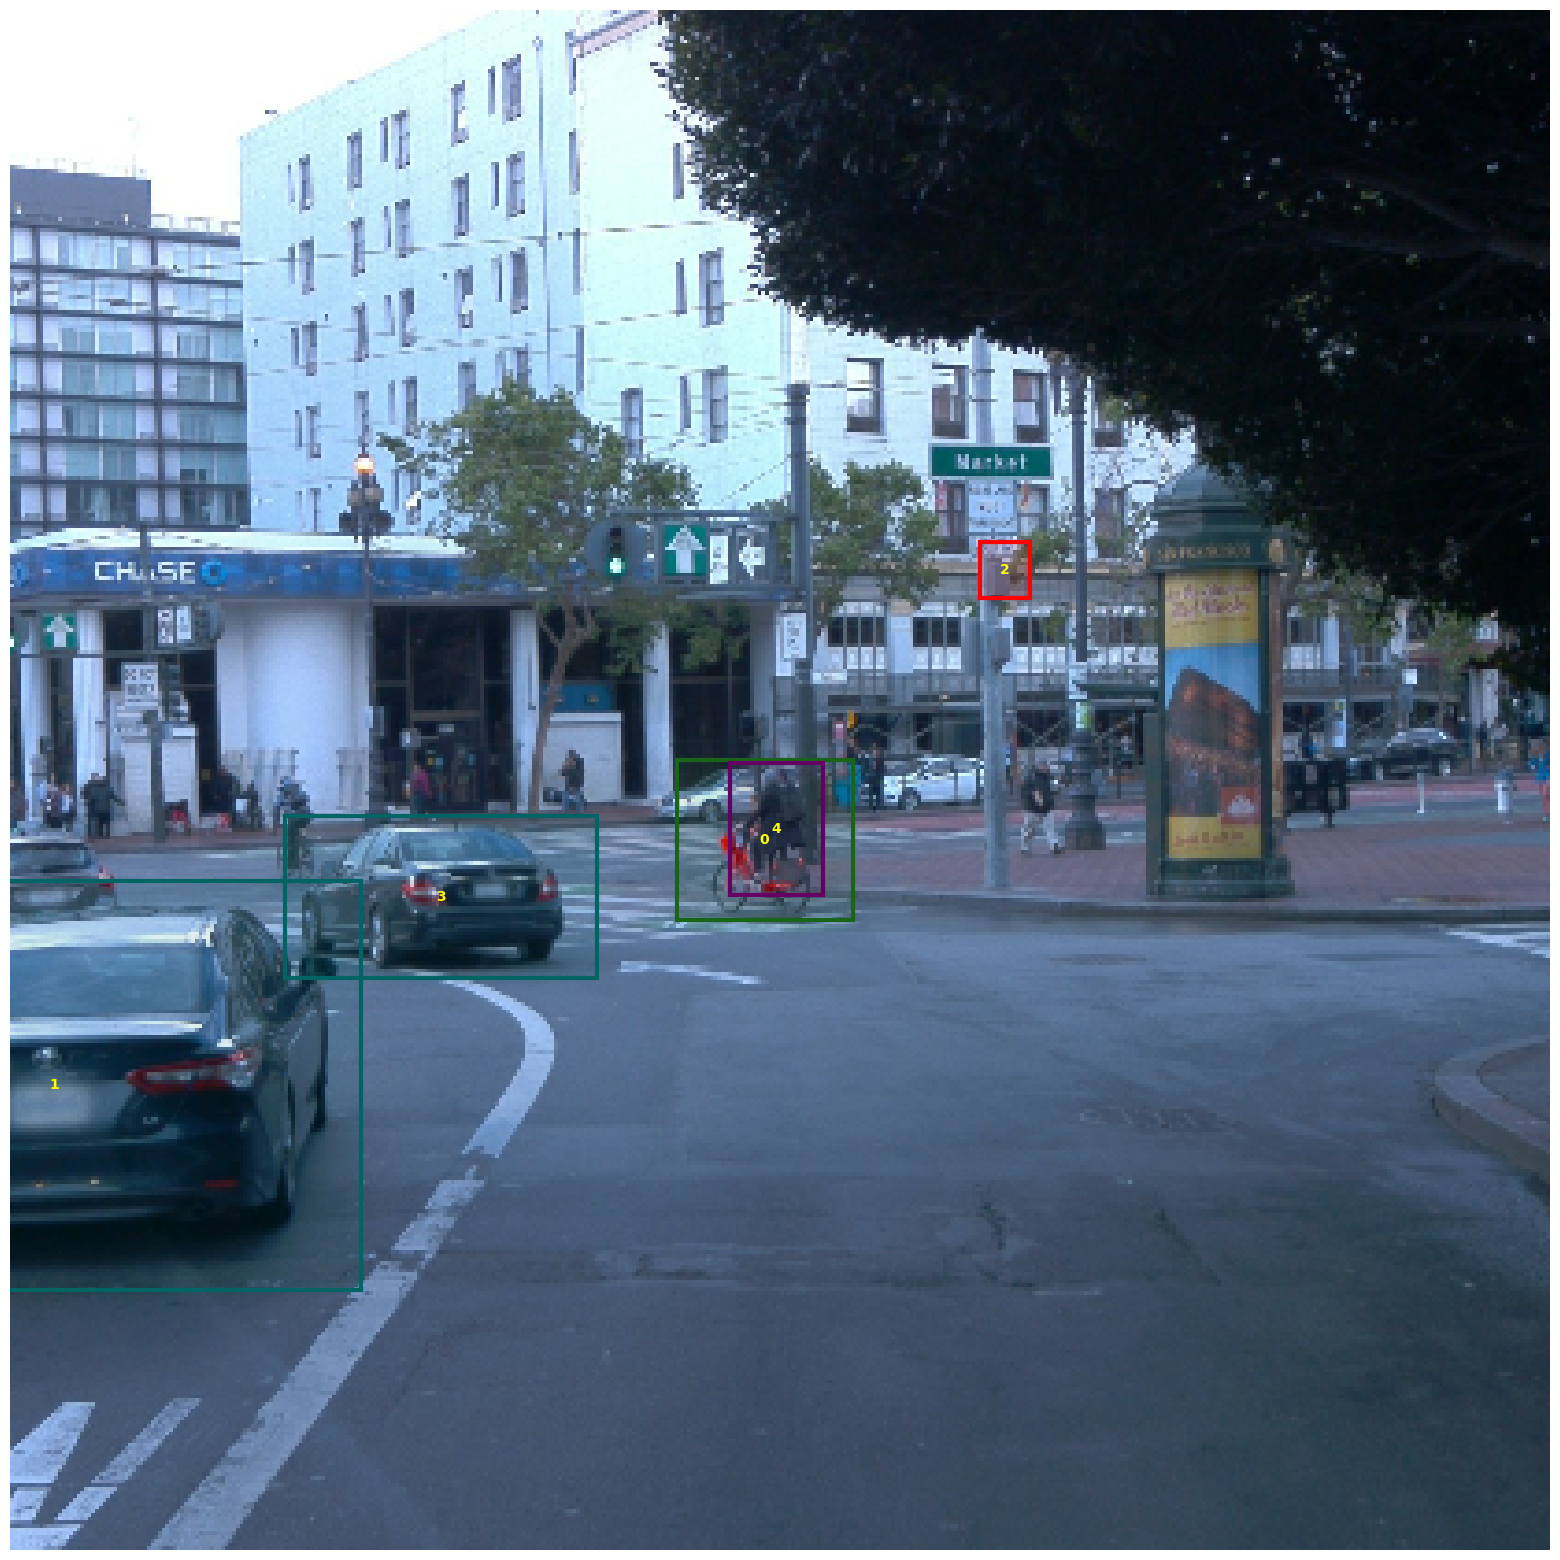

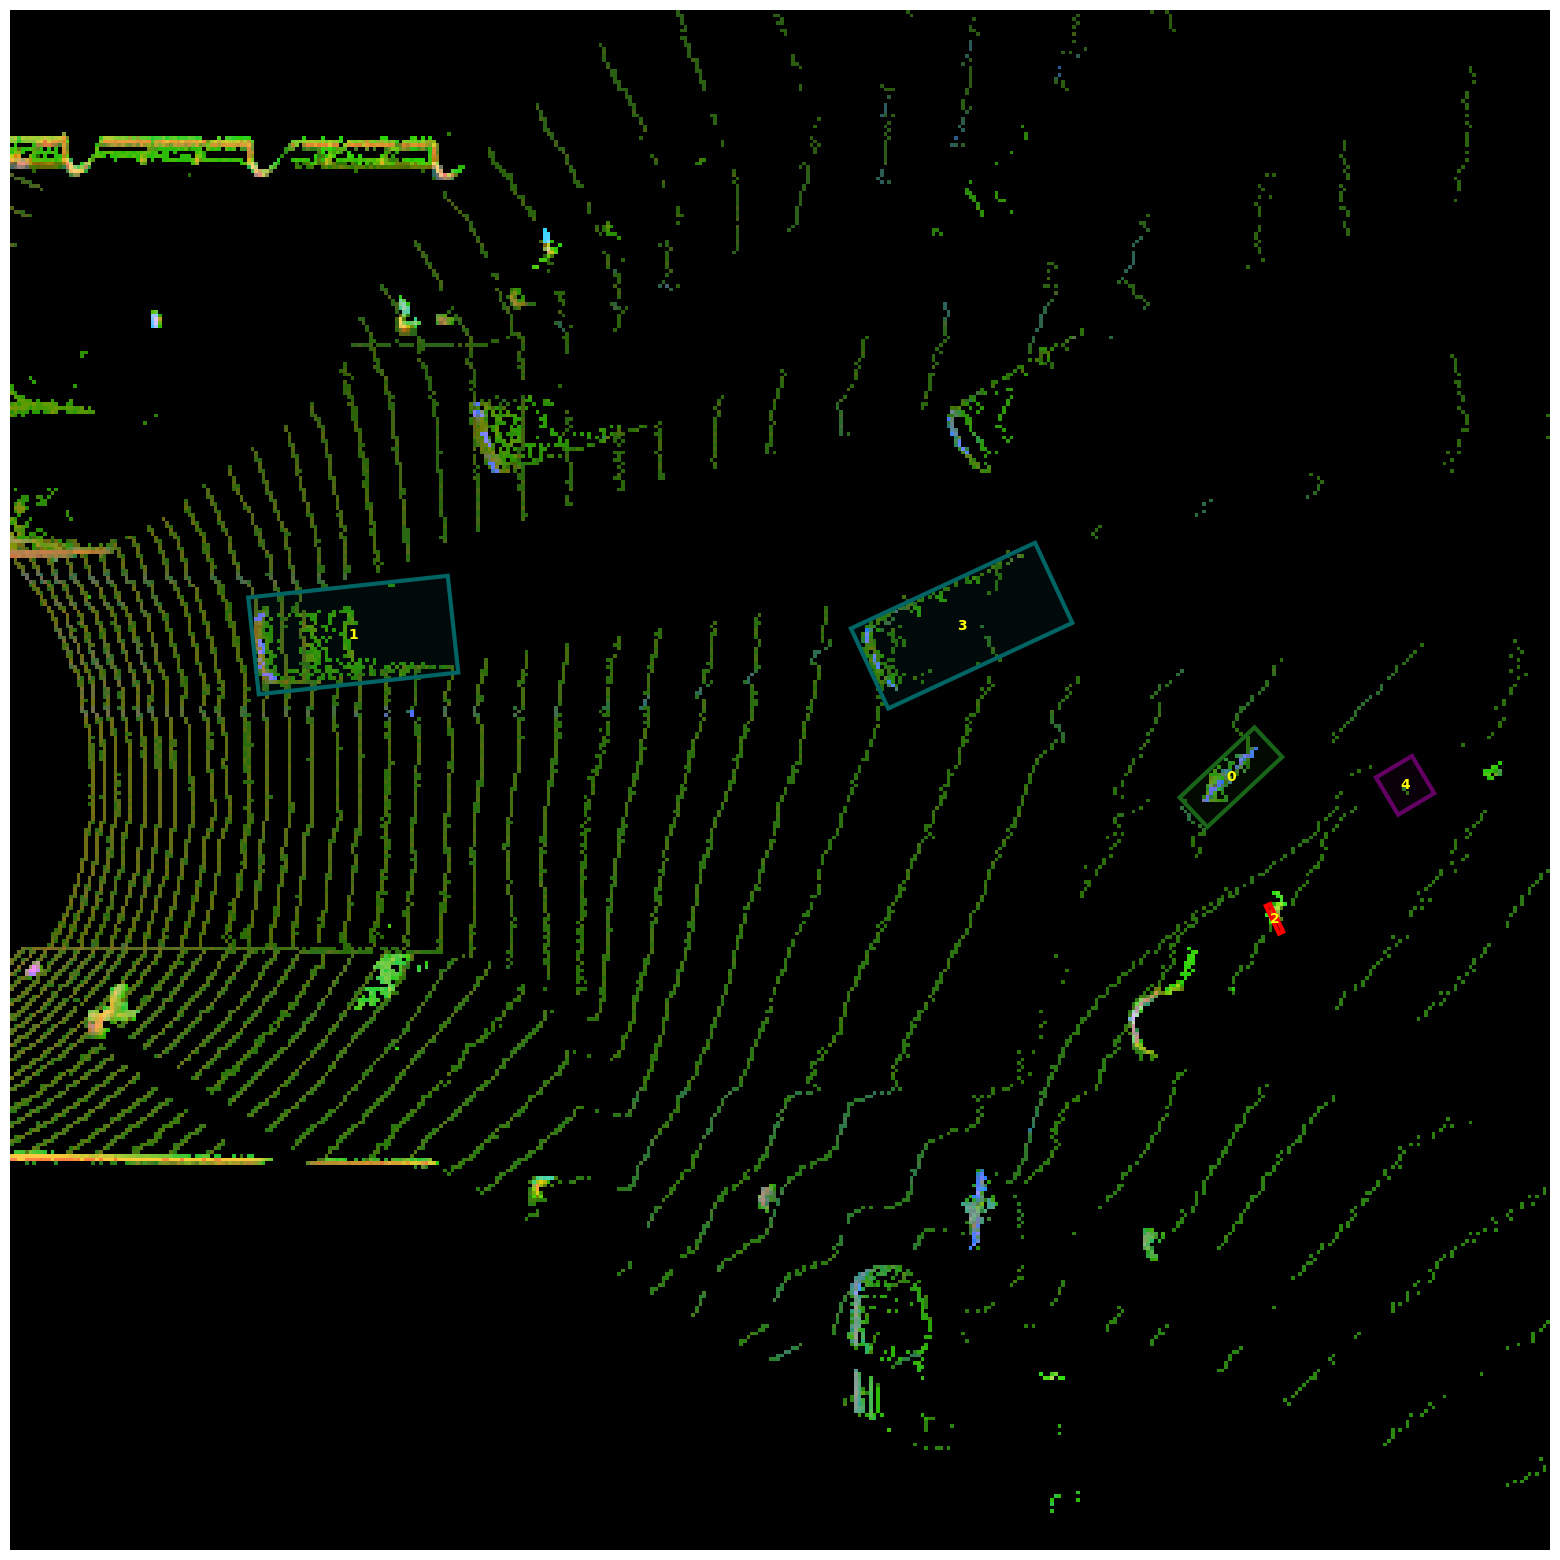

In [6]:
# Visualize saved data
waymo_to_yolo_img = mpimg.imread(path_img)
waymo_to_yolo_lidar = mpimg.imread(path_lidar)

# waymo_to_yolo_img = cv.resize(waymo_to_yolo_img, dsize=(configs['yolo_width'], configs['yolo_height']), interpolation=cv.INTER_CUBIC)
waymo_to_yolo_labels = read_boxes(path_lbs, waymo_to_yolo_img)

print(f'The shape of the data is {waymo_to_yolo_labels.shape} an an example line is {waymo_to_yolo_labels[0,:]}')

# lidar_boxes = np.zeros((waymo_to_yolo_labels[0], 6))
lidar_boxes = np.transpose(np.stack(np.array([
    waymo_to_yolo_labels[:,0],
    waymo_to_yolo_labels[:,5],
    waymo_to_yolo_labels[:,6],
    waymo_to_yolo_labels[:,7],
    waymo_to_yolo_labels[:,8],
    waymo_to_yolo_labels[:,9]])))

                                    
show_image(waymo_to_yolo_img, waymo_to_yolo_labels[:,:5])
show_image(waymo_to_yolo_lidar, lidar_boxes)

## Util

In [ ]:
def find_output_layers(input_size):
    print('yolo starts with ', input_size)
    size = input_size
    with open('yolo_architecture.txt') as yolo_arch:
        for i, line in enumerate(yolo_arch):
            block = line.split('(')
            if block[0] == 'CNNBlock':
                args = block[1].split(',')
                K = int(args[2].split('=')[1])
                S = int(args[3].split('=')[1])
                P = int(args[4][:-1].split('=')[1])
                size = ((size - K + (2 * P)) / S) + 1
                print(f'Output at layer {i} is {size}')

find_output_layers(416)

In [6]:
import pandas as pd

mydict = [{'a': 1, 'b': 2, 'c': 3, 'd': 4},
          {'a': 100, 'b': 200, 'c': 300, 'd': 400},
          {'a': 1000, 'b': 2000, 'c': 3000, 'd': 4000}]
df = pd.DataFrame(mydict)
df.iloc[1,2]

np.int64(300)

# Define constants

In [7]:
import mike_yolo3_utils
import mike_yolov3
 
import albumentations as A 
from albumentations.pytorch import ToTensorV2 
import cv2 

In [28]:
from importlib import reload  # Python 3.4+
reload(mike_yolo3_utils)

<module 'mike_yolo3_utils' from '/home/mike_yolo/src/mike_yolo3_utils.py'>

In [17]:
import torch

# Device 
device = "cuda" if torch.cuda.is_available() else "cpu"
available_gpus = [torch.cuda.device(i) for i in range(torch.cuda.device_count())]

print("GPUs Available: ", available_gpus)

# Define paths

dataset_dir_yolo = '/home/mike_yolo/src/data/perception_2.0.0_yolov8'
  
# Load and save model variable 
load_model = False
save_model = True
  
# model checkpoint file name 
checkpoint_file = "checkpoint.pth.tar"
  
# Anchor boxes for each feature map scaled between 0 and 1 
# 3 feature maps at 3 different scales based on YOLOv3 paper 
ANCHORS = [ 
    [(0.28, 0.22), (0.38, 0.48), (0.9, 0.78)], 
    [(0.07, 0.15), (0.15, 0.11), (0.14, 0.29)], 
    [(0.02, 0.03), (0.04, 0.07), (0.08, 0.06)], 
] 
  
# Batch size for training 
batch_size = 32
  
# Learning rate for training 
leanring_rate = 1e-5
  
# Number of epochs for training 
epochs = 20
  
# Image size 
image_size = 416
  
# Grid cell sizes 
s = [image_size // 32, image_size // 16, image_size // 8] 
  
# Class labels 
class_labels = [ 
    "vehicle", "pedestrian", "sign", "cyclist"
]

GPUs Available:  [<torch.cuda.device object at 0x7f617962d450>]


In [18]:
# Transform for training 
train_transform = A.Compose( 
    [ 
        # Rescale an image so that maximum side is equal to image_size 
        A.LongestMaxSize(max_size=image_size), 
        # Pad remaining areas with zeros 
        A.PadIfNeeded( 
            min_height=image_size, min_width=image_size, border_mode=cv2.BORDER_CONSTANT 
        ), 
        # Random color jittering 
        A.ColorJitter( 
            brightness=0.5, contrast=0.5, 
            saturation=0.5, hue=0.5, p=0.5
        ), 
        # Flip the image horizontally 
        A.HorizontalFlip(p=0.5), 
        # Normalize the image 
        A.Normalize( 
            mean=[0, 0, 0], std=[1, 1, 1], max_pixel_value=255
        ), 
        # Convert the image to PyTorch tensor 
        ToTensorV2() 
    ],  
    # Augmentation for bounding boxes 
    bbox_params=A.BboxParams( 
                    format="yolo",  
                    min_visibility=0.4,  
                    label_fields=[] 
                ) 
) 
  
# Transform for testing 
test_transform = A.Compose( 
    [ 
        # Rescale an image so that maximum side is equal to image_size 
        A.LongestMaxSize(max_size=image_size), 
        # Pad remaining areas with zeros 
        A.PadIfNeeded( 
            min_height=image_size, min_width=image_size, border_mode=cv2.BORDER_CONSTANT 
        ), 
        # Normalize the image 
        A.Normalize( 
            mean=[0, 0, 0], std=[1, 1, 1], max_pixel_value=255
        ), 
        # Convert the image to PyTorch tensor 
        ToTensorV2() 
    ], 
    # Augmentation for bounding boxes  
    bbox_params=A.BboxParams( 
                    format="yolo",  
                    min_visibility=0.4,  
                    label_fields=[] 
                ) 
)

In [30]:

# Creating a dataset object 
dataset = mike_yolo3_utils.Dataset( 
    csv_file=os.path.join(dataset_dir_yolo, 'training.csv'), 
    image_dir=os.path.join(dataset_dir_yolo, 'images', 'training'), 
    label_dir=os.path.join(dataset_dir_yolo, 'labels', 'training'), 
    grid_sizes=[13, 26, 52], 
    anchors=ANCHORS, 
    transform=test_transform 
) 
  
# Creating a dataloader object 
loader = torch.utils.data.DataLoader( 
    dataset=dataset, 
    batch_size=1, 
    shuffle=True, 
) 
  
# Defining the grid size and the scaled anchors 
GRID_SIZE = [13, 26, 52] 
scaled_anchors = torch.tensor(ANCHORS) / ( 
    1 / torch.tensor(GRID_SIZE).unsqueeze(1).unsqueeze(1).repeat(1, 3, 2) 
) 
  
# Getting a batch from the dataloader 
x, y = next(iter(loader)) 
  
# Getting the boxes coordinates from the labels 
# and converting them into bounding boxes without scaling 
boxes = [] 
for i in range(y[0].shape[1]): 
    anchor = scaled_anchors[i] 
    boxes += convert_cells_to_bboxes( 
               y[i], is_predictions=False, s=y[i].shape[2], anchors=anchor 
             )[0] 
  
# Applying non-maximum suppression 
boxes = nms(boxes, iou_threshold=1, threshold=0.7) 
  
# Plotting the image with the bounding boxes 
plot_image(x[0].permute(1,2,0).to("cpu"), boxes)

[[4.00000000e+00 4.88851780e-01 5.37766087e-01 1.14458250e-01
  1.03308314e-01 7.91606899e-01 4.96985574e-01 6.65669234e-02
  2.62956084e-02 3.80273991e-01]
 [1.00000000e+00 2.74234433e-02 6.97101476e-01 3.98878836e-01
  2.65345548e-01 2.21697707e-01 4.04667599e-01 1.30318208e-01
  6.32001250e-02 4.82740633e-01]
 [3.00000000e+00 6.45007172e-01 3.62472916e-01 3.22522665e-02
  3.61881405e-02 8.19916235e-01 5.88933836e-01 3.02129048e-03
  1.98548403e-02 9.28934938e-01]
 [1.00000000e+00 2.78604459e-01 5.74636462e-01 2.02851909e-01
  1.04850151e-01 6.16743086e-01 3.98572055e-01 1.31881892e-01
  5.73581946e-02 4.30713828e-01]
 [2.00000000e+00 4.96437262e-01 5.30720536e-01 6.03550760e-02
  8.53550230e-02 9.04693145e-01 5.02264673e-01 2.81917941e-02
  2.72450315e-02 1.64467119e-01]]


ValueError: In YOLO format all coordinates must be float and in range (0, 1], got [[4.0000000e+00 4.8885179e-01 5.3776610e-01 1.1445825e-01 1.0330831e-01
  7.9160690e-01 4.9698558e-01 6.6566922e-02 2.6295608e-02 3.8027400e-01]
 [1.0000000e+00 2.7423443e-02 6.9710147e-01 3.9887884e-01 2.6534554e-01
  2.2169770e-01 4.0466759e-01 1.3031821e-01 6.3200124e-02 4.8274064e-01]
 [3.0000000e+00 6.4500719e-01 3.6247292e-01 3.2252267e-02 3.6188141e-02
  8.1991625e-01 5.8893383e-01 3.0212905e-03 1.9854840e-02 9.2893493e-01]
 [1.0000000e+00 2.7860445e-01 5.7463646e-01 2.0285191e-01 1.0485015e-01
  6.1674309e-01 3.9857206e-01 1.3188189e-01 5.7358194e-02 4.3071383e-01]
 [2.0000000e+00 4.9643725e-01 5.3072053e-01 6.0355075e-02 8.5355021e-02
  9.0469313e-01 5.0226468e-01 2.8191794e-02 2.7245032e-02 1.6446713e-01]]

In [ ]:
  
# Creating model and testing output shapes 
model = YOLOv3(num_classes=num_classes) 
x = torch.randn((1, 3, IMAGE_SIZE, IMAGE_SIZE)) 
out = model(x) 
print(out[0].shape) 
print(out[1].shape) 
print(out[2].shape) 

# Asserting output shapes 
assert model(x)[0].shape == (1, 3, IMAGE_SIZE//32, IMAGE_SIZE//32, num_classes + 5) 
assert model(x)[1].shape == (1, 3, IMAGE_SIZE//16, IMAGE_SIZE//16, num_classes + 5) 
assert model(x)[2].shape == (1, 3, IMAGE_SIZE//8, IMAGE_SIZE//8, num_classes + 5) 
print("Output shapes are correct!")

In [ ]:
# Define the train function to train the model 
def training_loop(loader, model, optimizer, loss_fn, scaler, scaled_anchors): 
    # Creating a progress bar 
    progress_bar = tqdm(loader, leave=True) 
  
    # Initializing a list to store the losses 
    losses = [] 
  
    # Iterating over the training data 
    for _, (x, y) in enumerate(progress_bar): 
        x = x.to(device) 
        y0, y1, y2 = ( 
            y[0].to(device), 
            y[1].to(device), 
            y[2].to(device), 
        ) 
  
        with torch.cuda.amp.autocast(): 
            # Getting the model predictions 
            outputs = model(x) 
            # Calculating the loss at each scale 
            loss = ( 
                  loss_fn(outputs[0], y0, scaled_anchors[0]) 
                + loss_fn(outputs[1], y1, scaled_anchors[1]) 
                + loss_fn(outputs[2], y2, scaled_anchors[2]) 
            ) 
  
        # Add the loss to the list 
        losses.append(loss.item()) 
  
        # Reset gradients 
        optimizer.zero_grad() 
  
        # Backpropagate the loss 
        scaler.scale(loss).backward() 
  
        # Optimization step 
        scaler.step(optimizer) 
  
        # Update the scaler for next iteration 
        scaler.update() 
  
        # update progress bar with loss 
        mean_loss = sum(losses) / len(losses) 
        progress_bar.set_postfix(loss=mean_loss)